## Week 4 Day 4 - preparing the big project!

# The Sidekick

It's time to introduce:

1. Structured Outputs
2. A multi-agent flow

In [81]:
from typing import Annotated, TypedDict, List, Dict, Any, Optional
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from IPython.display import Image, display
import gradio as gr
import uuid
from dotenv import load_dotenv

In [82]:
load_dotenv(override=True)

True

### For structured outputs, we define a Pydantic object for the Schema

In [83]:
# First define a structured output

class EvaluatorOutput(BaseModel):
    feedback: str = Field(description="Feedback on the assistant's response")
    success_criteria_met: bool = Field(description="Whether the success criteria have been met")
    user_input_needed: bool = Field(description="True if more input is needed from the user, or clarifications, or the assistant is stuck")


### And for the State, we'll use TypedDict again

But now we have some real information to maintain!

The messages uses the reducer. The others are simply values that we overwrite with any state change.

In [84]:
# The state

class State(TypedDict):
    messages: Annotated[List[Any], add_messages]
    success_criteria: str
    feedback_on_work: Optional[str]
    success_criteria_met: bool
    user_input_needed: bool

In [85]:
# Get our async Playwright tools
# If you get a NotImplementedError here or later, see the Heads Up at the top of the 3_lab3 notebook

# Apply nest_asyncio at module level to allow nested event loops
import nest_asyncio
nest_asyncio.apply()

In [86]:
# Global variables to store tools and graph (initialized lazily in Gradio's event loop)
tools = None
graph = None
_initialized = False
playwright_instance = None  # Store playwright instance to keep browser tied to event loop

async def initialize_tools_and_graph():
    """Initialize browser, tools, and graph in the current event loop (Gradio's loop)"""
    global tools, graph, _initialized, playwright_instance
    
    if not _initialized:
        # Create browser with longer timeout for web searches
        # nest_asyncio is already applied at module level
        from playwright.async_api import async_playwright
        playwright_instance = await async_playwright().start()
        async_browser = await playwright_instance.chromium.launch(headless=False)
        
        # Create a default context with longer navigation timeout (120 seconds instead of 30)
        # This ensures all pages created in this context will have the longer timeout
        context = await async_browser.new_context()
        # Set default navigation timeout to 120 seconds (120000ms)
        context.set_default_navigation_timeout(120000)
        context.set_default_timeout(120000)
        
        # Monkey-patch the browser's new_context method to always use longer timeout
        original_new_context = async_browser.new_context
        async def new_context_with_timeout(**kwargs):
            ctx = await original_new_context(**kwargs)
            ctx.set_default_navigation_timeout(120000)
            ctx.set_default_timeout(120000)
            return ctx
        async_browser.new_context = new_context_with_timeout
        
        # Use the browser with the configured context
        toolkit = PlayWrightBrowserToolkit.from_browser(async_browser=async_browser)
        tools = toolkit.get_tools()
        
        # Rebind LLM with tools
        global worker_llm_with_tools
        worker_llm_with_tools = worker_llm.bind_tools(tools)
        
        # Rebuild the graph with the new tools
        graph_builder = StateGraph(State)
        graph_builder.add_node("worker", worker)
        graph_builder.add_node("tools", ToolNode(tools=tools))
        graph_builder.add_node("evaluator", evaluator)
        graph_builder.add_conditional_edges("worker", worker_router, {"tools": "tools", "evaluator": "evaluator"})
        graph_builder.add_edge("tools", "worker")
        graph_builder.add_conditional_edges("evaluator", route_based_on_evaluation, {"worker": "worker", "END": END})
        graph_builder.add_edge(START, "worker")
        
        memory = MemorySaver()
        graph = graph_builder.compile(checkpointer=memory)
        _initialized = True
    
    return graph

In [87]:
# Initialize the LLMs
# Note: worker_llm_with_tools will be created lazily when tools are initialized

worker_llm = ChatOpenAI(model="gpt-4o-mini")
worker_llm_with_tools = None  # Will be set in initialize_tools_and_graph()

evaluator_llm = ChatOpenAI(model="gpt-4o-mini")
evaluator_llm_with_output = evaluator_llm.with_structured_output(EvaluatorOutput)

In [88]:
# The worker node

def worker(state: State) -> Dict[str, Any]:
    system_message = f"""You are a helpful assistant that can use tools to complete tasks.
You keep working on a task until either you have a question or clarification for the user, or the success criteria is met.
This is the success criteria:
{state['success_criteria']}

IMPORTANT: When searching the web or using browser tools, take your time to be thorough:
- Perform multiple searches if needed to gather comprehensive information
- Visit multiple websites to get different perspectives
- Read through the content carefully before summarizing
- Don't rush - thorough research takes time and multiple tool calls
- You can use tools multiple times in sequence to gather all necessary information

You should reply either with a question for the user about this assignment, or with your final response.
If you have a question for the user, you need to reply by clearly stating your question. An example might be:

Question: please clarify whether you want a summary or a detailed answer

If you've finished, reply with the final answer, and don't ask a question; simply reply with the answer.
"""
    
    if state.get("feedback_on_work"):
        system_message += f"""
Previously you thought you completed the assignment, but your reply was rejected because the success criteria was not met.
Here is the feedback on why this was rejected:
{state['feedback_on_work']}
With this feedback, please continue the assignment, ensuring that you meet the success criteria or have a question for the user."""
    
    # Add in the system message

    found_system_message = False
    messages = state["messages"]
    for message in messages:
        if isinstance(message, SystemMessage):
            message.content = system_message
            found_system_message = True
    
    if not found_system_message:
        messages = [SystemMessage(content=system_message)] + messages
    
    # Invoke the LLM with tools
    response = worker_llm_with_tools.invoke(messages)
    
    # Return updated state
    return {
        "messages": [response],
    }

In [89]:
def worker_router(state: State) -> str:
    last_message = state["messages"][-1]
    
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    else:
        return "evaluator"

In [90]:
def format_conversation(messages: List[Any]) -> str:
    conversation = "Conversation history:\n\n"
    for message in messages:
        if isinstance(message, HumanMessage):
            conversation += f"User: {message.content}\n"
        elif isinstance(message, AIMessage):
            text = message.content or "[Tools use]"
            conversation += f"Assistant: {text}\n"
    return conversation

In [91]:
# Node 3: Evaluator
def evaluator(state: State) -> State:
    # Get the last AI message content (skip tool results)
    last_response = ""
    for msg in reversed(state["messages"]):
        if isinstance(msg, AIMessage) and msg.content:
            last_response = msg.content
            break
    if not last_response:
        last_response = state["messages"][-1].content if hasattr(state["messages"][-1], 'content') else ""

    system_message = """You are an evaluator that determines if a task has been completed successfully by an Assistant.
Assess the Assistant's last response based on the given criteria. Respond with your feedback, and with your decision on whether the success criteria has been met,
and whether more input is needed from the user."""
    
    user_message = f"""You are evaluating a conversation between the User and Assistant. You decide what action to take based on the last response from the Assistant.

The entire conversation with the assistant, with the user's original request and all replies, is:
{format_conversation(state['messages'])}

The success criteria for this assignment is:
{state['success_criteria']}

And the final response from the Assistant that you are evaluating is:
{last_response}

Respond with your feedback, and decide if the success criteria is met by this response.
Also, decide if more user input is required, either because the assistant has a question, needs clarification, or seems to be stuck and unable to answer without help.

IMPORTANT: If the Assistant is still actively using tools (like web searches, browser navigation, etc.) to gather information, 
do NOT mark success_criteria_met as True yet. Allow the Assistant to complete their research and tool usage before evaluating.
Only mark success_criteria_met as True when the Assistant provides a final, complete answer without any pending tool calls.
"""
    if state["feedback_on_work"]:
        user_message += f"Also, note that in a prior attempt from the Assistant, you provided this feedback: {state['feedback_on_work']}\n"
        user_message += "If you're seeing the Assistant repeating the same mistakes, then consider responding that user input is required."
    
    evaluator_messages = [SystemMessage(content=system_message), HumanMessage(content=user_message)]

    # The evaluator has a structured output 
    eval_result = evaluator_llm_with_output.invoke(evaluator_messages)
    new_state = {
        "messages": [AIMessage(content=f"Evaluator Feedback on this answer: {eval_result.feedback}")],
        "feedback_on_work": eval_result.feedback,
        "success_criteria_met": eval_result.success_criteria_met,
        "user_input_needed": eval_result.user_input_needed
    }
    return new_state #new state is the state that will be passed to the next node

In [92]:
def route_based_on_evaluation(state: State) -> str:
    if state["success_criteria_met"] or state["user_input_needed"]:
        return "END"
    else:
        return "worker"

In [93]:
# Graph will be initialized lazily in Gradio's event loop
# The graph is created in the initialize_tools_and_graph() function
# This ensures the browser is created in the correct event loop context

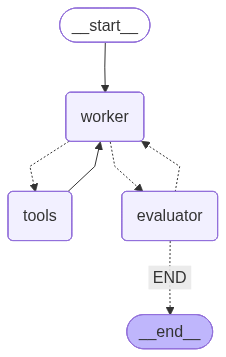

In [94]:
# Initialize graph for visualization (in notebook event loop)
# Note: This creates a temporary graph for visualization only
# The actual graph will be recreated in Gradio's event loop
import asyncio
import nest_asyncio
nest_asyncio.apply()

# Create a temporary graph for visualization without marking as initialized
if graph is None:
    # Temporarily allow initialization
    global _initialized
    old_initialized = _initialized
    _initialized = False
    
    # Initialize in notebook loop
    asyncio.run(initialize_tools_and_graph())
    
    # Reset flag so Gradio will recreate in its own loop
    _initialized = False
    # Clear the browser/tools so Gradio creates fresh ones
    global tools, playwright_instance
    tools = None
    playwright_instance = None

# Display the graph
display(Image(graph.get_graph().draw_mermaid_png()))

### Next comes the gradio Callback to kick off a super-step

In [95]:
def make_thread_id() -> str:
    return str(uuid.uuid4())


async def process_message(message, success_criteria, history, thread):
    # Initialize browser, tools, and graph in Gradio's event loop if not already done
    await initialize_tools_and_graph()

    config = {"configurable": {"thread_id": thread}}

    # Convert string message to HumanMessage
    user_message = HumanMessage(content=message)
    
    state = {
        "messages": [user_message],
        "success_criteria": success_criteria,
        "feedback_on_work": None,
        "success_criteria_met": False,
        "user_input_needed": False
    }
    result = await graph.ainvoke(state, config=config)
    
    # Extract the final assistant response and evaluator feedback
    # The last message should be the evaluator feedback, and the second-to-last should be the assistant's response
    user = {"role": "user", "content": message}
    
    # Find the last AIMessage (assistant response) and the evaluator feedback
    assistant_response = None
    evaluator_feedback = None
    
    for msg in reversed(result["messages"]):
        if isinstance(msg, AIMessage):
            if assistant_response is None:
                assistant_response = msg.content or ""
            elif evaluator_feedback is None and "Evaluator Feedback" in (msg.content or ""):
                evaluator_feedback = msg.content or ""
                break
    
    # Fallback: use last two messages if we couldn't find them properly
    if assistant_response is None and len(result["messages"]) >= 2:
        assistant_response = result["messages"][-2].content if hasattr(result["messages"][-2], 'content') else str(result["messages"][-2])
    if evaluator_feedback is None and len(result["messages"]) >= 1:
        evaluator_feedback = result["messages"][-1].content if hasattr(result["messages"][-1], 'content') else str(result["messages"][-1])
    
    reply = {"role": "assistant", "content": assistant_response or "No response"}
    feedback = {"role": "assistant", "content": evaluator_feedback or "No feedback"}
    return history + [user, reply, feedback]

async def reset():
    return "", "", None, make_thread_id()



### And now launch our Sidekick UI

In [ ]:

with gr.Blocks(theme=gr.themes.Default(primary_hue="emerald")) as demo:
    gr.Markdown("## Sidekick Personal Co-worker")
    thread = gr.State(make_thread_id())
    
    with gr.Row():
        chatbot = gr.Chatbot(label="Sidekick", height=300)
    with gr.Group():
        with gr.Row():
            message = gr.Textbox(show_label=False, placeholder="Your request to your sidekick")
        with gr.Row():
            success_criteria = gr.Textbox(show_label=False, placeholder="What are your success critiera?")
    with gr.Row():
        reset_button = gr.Button("Reset", variant="stop")
        go_button = gr.Button("Go!", variant="primary")
    message.submit(process_message, [message, success_criteria, chatbot, thread], [chatbot])
    success_criteria.submit(process_message, [message, success_criteria, chatbot, thread], [chatbot])
    go_button.click(process_message, [message, success_criteria, chatbot, thread], [chatbot])
    reset_button.click(reset, [], [message, success_criteria, chatbot, thread])

    
demo.launch()

/tmp/ipykernel_78370/2834228219.py:1: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Default(primary_hue="emerald")) as demo:


* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "/home/my_projects/wsl_env/lib/python3.10/site-packages/gradio/queueing.py", line 766, in process_events
    response = await route_utils.call_process_api(
  File "/home/my_projects/wsl_env/lib/python3.10/site-packages/gradio/route_utils.py", line 355, in call_process_api
    output = await app.get_blocks().process_api(
  File "/home/my_projects/wsl_env/lib/python3.10/site-packages/gradio/blocks.py", line 2152, in process_api
    result = await self.call_function(
  File "/home/my_projects/wsl_env/lib/python3.10/site-packages/gradio/blocks.py", line 1627, in call_function
    prediction = await fn(*processed_input)
  File "/home/my_projects/wsl_env/lib/python3.10/site-packages/gradio/utils.py", line 1003, in async_wrapper
    response = await f(*args, **kwargs)
  File "/tmp/ipykernel_78370/237059951.py", line 21, in process_message
    result = await graph.ainvoke(state, config=config)
  File "/home/my_projects/wsl_env/lib/python3.10/site-packa

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/thanks.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#00cc00;">Congratulations on making the first version of Sidekick!</h2>
            <span style="color:#00cc00;">This is a pretty epic moment in the course. You've made the start of something very powerful. And you've upskilled on an impressive Agent framework in LangGraph. Maybe like me you're being converted from a LangGraph skeptic to a LangGraph fan..<br/><br/>My editor would kill me if I didn't mention again: if you're able to rate the course on Udemy, I'd be so very grateful: it's the main way that Udemy decides whether to show the course to others and it makes a massive difference.<br/><br/>And another reminder that I love <a href="https://www.linkedin.com/in/eddonner/">connecting on LinkedIn</a> if you haven't yet! If you wanted to post about your progress on the course, please tag me and I'll weigh in to increase your exposure.
            </span>
        </td>
    </tr>